# 🩺 CBIS-DDSM Tumor Detection Training

This notebook trains detection models (YOLOv8, YOLOv5, Faster R-CNN) on the CBIS-DDSM mammography dataset for lesion detection and classification (benign vs malignant).

**Prerequisites:**
- Preprocessed CBIS-DDSM dataset (run `cbis_ddsm_preprocessor.py` first)
- JPEG images uploaded to Google Drive

**GPU:** Make sure to enable GPU: Runtime → Change runtime type → T4 GPU

## 1️⃣ Setup & Mount Drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

os.chdir('/content')

# Path to your uploaded dataset
zip_path = '/content/drive/MyDrive/CBIS-DDSM.zip'

print("Extracting dataset... (this may take a few minutes)")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("✓ Dataset extracted to /content/CBIS-DDSM/")

# Verify
!ls -lh /content/CBIS-DDSM/

Extracting dataset... (this may take a few minutes)
✓ Dataset extracted to /content/CBIS-DDSM/
total 700K
drwxr-xr-x    2 root root 4.0K Feb  5 18:50 csv
drwxr-xr-x 6776 root root 688K Feb  5 18:52 jpeg
drwxr-xr-x    2 root root 4.0K Feb  5 18:52 processed


In [ ]:
# Check GPU
!nvidia-smi

Thu Feb  5 18:52:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Install dependencies
!pip install -q ultralytics
!pip install -q pandas numpy pillow tqdm pyyaml

print("\n✓ Dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.4 MB/s eta 0:00:00

✓ Dependencies installed!


## 2️⃣ Configuration

**⚠️ IMPORTANT: Update these paths to match your Google Drive structure!**

In [ ]:
# =============================================================================
# CONFIGURATION - UPDATE THESE PATHS!
# =============================================================================

class Config:
    # Path to preprocessed CSV from cbis_ddsm_preprocessor.py
    PREPROCESSED_CSV = '/content/CBIS-DDSM/processed/cbis_ddsm_linked.csv'

    # Path to CBIS-DDSM JPEG images root (contains CBIS-DDSM/jpeg folder)
    DATA_ROOT = '/content'

    # Output directory (results saved here)
    OUTPUT_DIR = '/content/drive/MyDrive/CBIS-DDSM/training_output'

    # Local working directory (faster than Drive)
    YOLO_DATASET_DIR = '/content/cbis_ddsm_yolo'

    # Model selection: 'yolov5', 'yolov8', 'yolov11', 'faster_rcnn'
    MODEL = 'yolov8'

    # Classes
    CLASSES = ['benign', 'malignant']
    NUM_CLASSES = 2
    PATHOLOGY_TO_CLASS = {
        'BENIGN': 0,
        'BENIGN_WITHOUT_CALLBACK': 0,
        'MALIGNANT': 1
    }

    # Training parameters
    EPOCHS = 100
    BATCH_SIZE = 8  # Reduce to 8 if you get OOM errors
    IMG_SIZE = 1024   # Can increase to 1024 for better detail
    LEARNING_RATE = 1e-4

    # Device
    DEVICE = 'cuda'
    NUM_WORKERS = 2

config = Config()

# Verify paths exist
import os
print("Checking paths...")
print(f"  CSV exists: {os.path.exists(config.PREPROCESSED_CSV)}")
print(f"  Data root exists: {os.path.exists(config.DATA_ROOT)}")

if not os.path.exists(config.PREPROCESSED_CSV):
    print("\n⚠️ ERROR: Preprocessed CSV not found! Update PREPROCESSED_CSV path.")
if not os.path.exists(config.DATA_ROOT):
    print("\n⚠️ ERROR: Data root not found! Update DATA_ROOT path.")

Checking paths...
  CSV exists: True
  Data root exists: True


## 3️⃣ Convert Dataset to YOLO Format

This converts the preprocessed CSV + images into YOLO format with bounding boxes extracted from ROI masks.

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import yaml

def convert_to_yolo_format(config, force_reconvert=False):
    """Convert CBIS-DDSM to YOLO format."""
    output_dir = Path(config.YOLO_DATASET_DIR)
    yaml_path = output_dir / 'dataset.yaml'

    if yaml_path.exists() and not force_reconvert:
        print(f"✓ YOLO dataset already exists at {output_dir}")
        return str(yaml_path)

    print(f"\nConverting CBIS-DDSM to YOLO format...")

    # Load data
    df = pd.read_csv(config.PREPROCESSED_CSV)
    print(f"  Total samples: {len(df)}")

    # Filter valid samples
    df = df[df['full_mammogram_path'].notna() & df['roi_mask_path'].notna()].reset_index(drop=True)
    print(f"  Valid samples: {len(df)}")

    # Create directories
    for split in ['train', 'val', 'test']:
        (output_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
        (output_dir / 'labels' / split).mkdir(parents=True, exist_ok=True)

    stats = {'train': 0, 'val': 0, 'test': 0, 'skipped': 0}

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Converting"):
        split = row.get('dataset_split', 'train')
        if split not in ['train', 'val', 'test']:
            split = 'train'

        # Load mammogram
        mammogram_path = os.path.join(config.DATA_ROOT, row['full_mammogram_path'])
        if not os.path.exists(mammogram_path):
            stats['skipped'] += 1
            continue

        try:
            mammogram = Image.open(mammogram_path)
            orig_w, orig_h = mammogram.size

            # Load mask
            mask_path = os.path.join(config.DATA_ROOT, row['roi_mask_path'])
            mask = Image.open(mask_path).convert('L')
            if mask.size != mammogram.size:
                mask = mask.resize(mammogram.size, Image.Resampling.NEAREST)

            mask_array = np.array(mask)

            # Find bounding box
            rows_with_content = np.any(mask_array > 127, axis=1)
            cols_with_content = np.any(mask_array > 127, axis=0)

            if not rows_with_content.any():
                stats['skipped'] += 1
                continue

            y_min, y_max = np.where(rows_with_content)[0][[0, -1]]
            x_min, x_max = np.where(cols_with_content)[0][[0, -1]]

            # YOLO format
            x_center = ((x_min + x_max) / 2) / orig_w
            y_center = ((y_min + y_max) / 2) / orig_h
            width = (x_max - x_min) / orig_w
            height = (y_max - y_min) / orig_h

            # Class
            pathology = row.get('pathology', 'BENIGN')
            class_id = config.PATHOLOGY_TO_CLASS.get(pathology, 0)

            # Filename
            patient_id = row.get('patient_id', f'sample_{idx}')
            laterality = row.get('left_or_right_breast', row.get('laterality', 'UNK'))
            view = row.get('image_view', row.get('view', 'UNK'))
            abnormality_id = row.get('abnormality_id', 1)
            filename = f"{patient_id}_{laterality}_{view}_{abnormality_id}"

            # Save image
            img_resized = mammogram.convert('RGB').resize((config.IMG_SIZE, config.IMG_SIZE), Image.Resampling.BILINEAR)
            img_resized.save(output_dir / 'images' / split / f"{filename}.jpg", quality=95)

            # Save label
            with open(output_dir / 'labels' / split / f"{filename}.txt", 'w') as f:
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

            stats[split] += 1

        except Exception as e:
            stats['skipped'] += 1
            continue

    print(f"\n  Train: {stats['train']}, Val: {stats['val']}, Test: {stats['test']}, Skipped: {stats['skipped']}")

    # Create YAML
    yaml_content = {
        'path': str(output_dir),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'nc': config.NUM_CLASSES,
        'names': config.CLASSES
    }

    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f)

    print(f"✓ Created dataset.yaml")
    return str(yaml_path)

# Run conversion
dataset_yaml = convert_to_yolo_format(config, force_reconvert=False)


Converting CBIS-DDSM to YOLO format...
  Total samples: 3568
  Valid samples: 3242


Converting: 100%|██████████| 3242/3242 [13:06<00:00,  4.12it/s]


  Train: 2433, Val: 430, Test: 379, Skipped: 0
✓ Created dataset.yaml


## 4️⃣ Visualize Sample Data

Quick sanity check to make sure the conversion worked correctly.

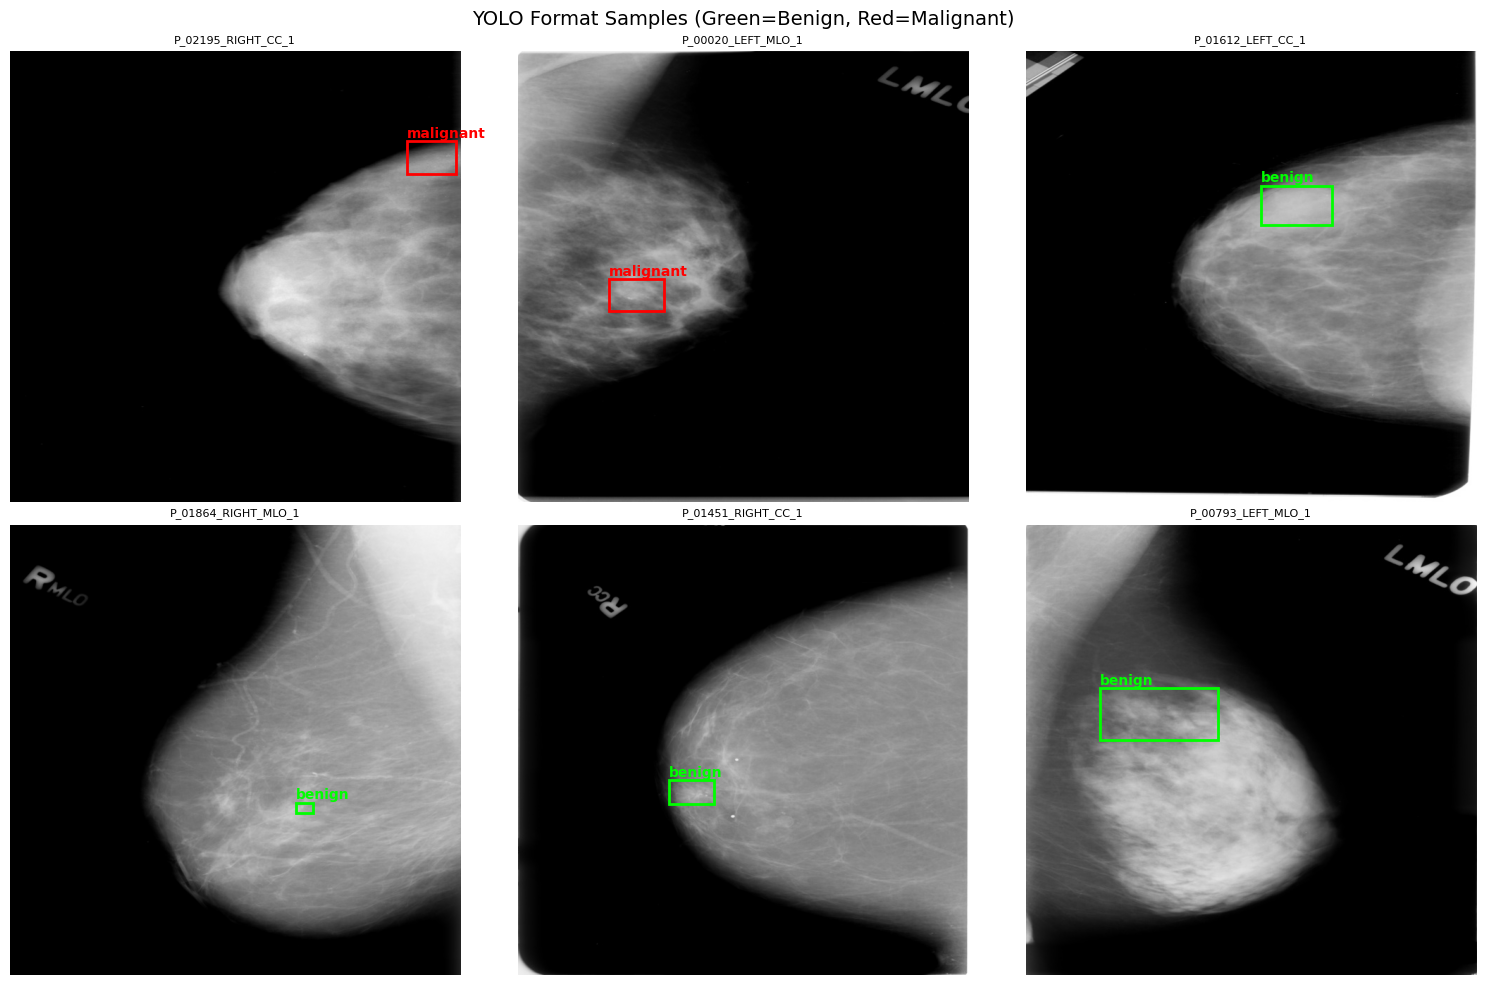

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def visualize_yolo_samples(config, num_samples=6):
    """Visualize converted YOLO samples."""
    images_dir = Path(config.YOLO_DATASET_DIR) / 'images' / 'train'
    labels_dir = Path(config.YOLO_DATASET_DIR) / 'labels' / 'train'

    image_files = list(images_dir.glob('*.jpg'))
    samples = random.sample(image_files, min(num_samples, len(image_files)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, img_path in enumerate(samples):
        ax = axes[idx]

        # Load image
        img = Image.open(img_path)
        ax.imshow(img, cmap='gray')

        # Load label
        label_path = labels_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])

                    # Convert to pixels
                    img_w, img_h = img.size
                    x1 = (x_center - width/2) * img_w
                    y1 = (y_center - height/2) * img_h
                    w = width * img_w
                    h = height * img_h

                    color = 'lime' if class_id == 0 else 'red'
                    label = config.CLASSES[class_id]

                    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1-5, label, color=color, fontsize=10, fontweight='bold')

        ax.set_title(img_path.stem[:30], fontsize=8)
        ax.axis('off')

    plt.suptitle('YOLO Format Samples (Green=Benign, Red=Malignant)', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_yolo_samples(config)

## 5️⃣ Train Model

Now we train the detection model!

In [ ]:
from ultralytics import YOLO
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
# =============================================================================
# TRAIN YOLO MODEL
# =============================================================================

from ultralytics import YOLO
# # Uncomment for training from scratch
# import os

# # Create output directory
# os.makedirs(config.OUTPUT_DIR, exist_ok=True)

# # Select model
# model_weights = {
#     'yolov5': 'yolov5l.pt',
#     'yolov8': 'yolov8l.pt',
#     'yolov11': 'yolo11l.pt',
# }[config.MODEL]

# print(f"\n{'='*60}")
# print(f"Training {config.MODEL.upper()}")
# print(f"{'='*60}")
# print(f"  Weights: {model_weights}")
# print(f"  Epochs: {config.EPOCHS}")
# print(f"  Batch size: {config.BATCH_SIZE}")
# print(f"  Image size: {config.IMG_SIZE}")
# print(f"  Classes: {config.CLASSES}")

# # Load model
# model = YOLO(model_weights)

# For pre-trained models from digitaleye
import urllib.request

# Download mammography-pretrained weights
urllib.request.urlretrieve(
    "https://github.com/ddobvyz/digitaleye-mammography/releases/download/shared-models.v2/yolo11_l.pt",
    "yolo11_mammography.pt"
)

# Fine-tune on your CBIS-DDSM data
model = YOLO("yolo11_mammography.pt")

# Train!
results = model.train(
    data=dataset_yaml,
    # Training params
    epochs=75,
    patience=25,
    batch=8,
    imgsz=1024,

    # Learning rate - CORRECTED for fine-tuning
    lr0=0.00001,       # 1e-5 (very small for fine-tuning)
    lrf=0.1,           # Final LR = lr0 * lrf = 1e-6
    warmup_epochs=3,

    # Optimizer
    optimizer='AdamW',
    weight_decay=0.0005,

    # Augmentation - CORRECTED
    augment=True,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    flipud=0.0,        # OFF - anatomically impossible
    fliplr=0.5,        # OK - simulates left/right breast
    degrees=5,         # Small rotation only
    translate=0.1,
    scale=0.2,
    shear=0.0,
    perspective=0.0,
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.1,

    # Detection settings
    iou=0.5,
    max_det=10,

    # Output
    project='/content/drive/MyDrive/CBIS-DDSM/training_output',
    name='yolo11_mammography_v2',
    save=True,
    save_period=10,
    plots=True,

    device=0,
    workers=2,
)

print("\n✓ Training complete!")

       1/75      12.6G      2.342      3.357      2.477          1       1024: 100% ━━━━━━━━━━━━ 305/305 1.0it/s 4:55
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.2it/s 22.5s
                   all        430        430      0.261      0.201      0.125     0.0464

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/75        13G      2.175      2.979      2.307          1       1024: 100% ━━━━━━━━━━━━ 305/305 1.1it/s 4:29
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.5it/s 17.8s
                   all        430        430      0.301      0.217      0.156     0.0553

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/75        13G       2.13        2.9      2.268          1       1024: 100% ━━━━━━━━━━━━ 305/305 1.1it/s 4:28
                 Class     Images  Instances      Box(

Exception ignored in: <function Socket.__del__ at 0x7b960540b4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/zmq/sugar/socket.py", line 181, in __del__
    def __del__(self):

KeyboardInterrupt: 



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      66/75        13G      1.958      2.463      2.089          1       1024: 100% ━━━━━━━━━━━━ 305/305 1.1it/s 4:29
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.5it/s 17.8s
                   all        430        430      0.373       0.26      0.258      0.107

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      67/75        13G      1.967      2.491      2.084          1       1024: 100% ━━━━━━━━━━━━ 305/305 1.1it/s 4:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.5it/s 17.9s
                   all        430        430      0.371      0.268      0.263       0.11

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      68/75        13G      1.948      2.486      2.075          1       1024: 100% ━━━━━━━━━

## 6️⃣ Evaluate on Test Set

In [ ]:
# Find best model
from pathlib import Path

model_dirs = sorted(Path(config.OUTPUT_DIR).glob(f'{config.MODEL}_cbis_ddsm*'))
if model_dirs:
    best_model_path = model_dirs[-1] / 'weights' / 'best.pt'
    print(f"Best model: {best_model_path}")

    # Load and evaluate
    model = YOLO(best_model_path)

    results = model.val(
        data=dataset_yaml,
        split='test',
        imgsz=config.IMG_SIZE,
        batch=config.BATCH_SIZE,
        device=0,
    )

    print(f"\n{'='*40}")
    print("TEST RESULTS")
    print(f"{'='*40}")
    print(f"  mAP@50:    {results.box.map50:.4f}")
    print(f"  mAP@50-95: {results.box.map:.4f}")
    print(f"  Precision: {results.box.mp:.4f}")
    print(f"  Recall:    {results.box.mr:.4f}")
else:
    print("No trained model found!")

Best model: /content/drive/MyDrive/CBIS-DDSM/training_output/yolov8_cbis_ddsm2/weights/best.pt
Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11l summary (fused): 191 layers, 25,280,854 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 34.0±5.9 MB/s, size: 51.3 KB)
val: Scanning /content/cbis_ddsm_yolo/labels/test... 379 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 379/379 1.0Kit/s 0.4s
val: New cache created: /content/cbis_ddsm_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 1.6it/s 14.6s
                   all        379        379      0.584      0.509      0.482        0.2
                benign        231        231      0.605      0.424      0.437      0.175
             malignant        148        148      0.563      0.595      0.527      0.226
Speed: 1.9ms preprocess, 32.9ms inference, 0.0ms loss, 0.8ms postp

## 7️⃣ Run Inference on Sample Images

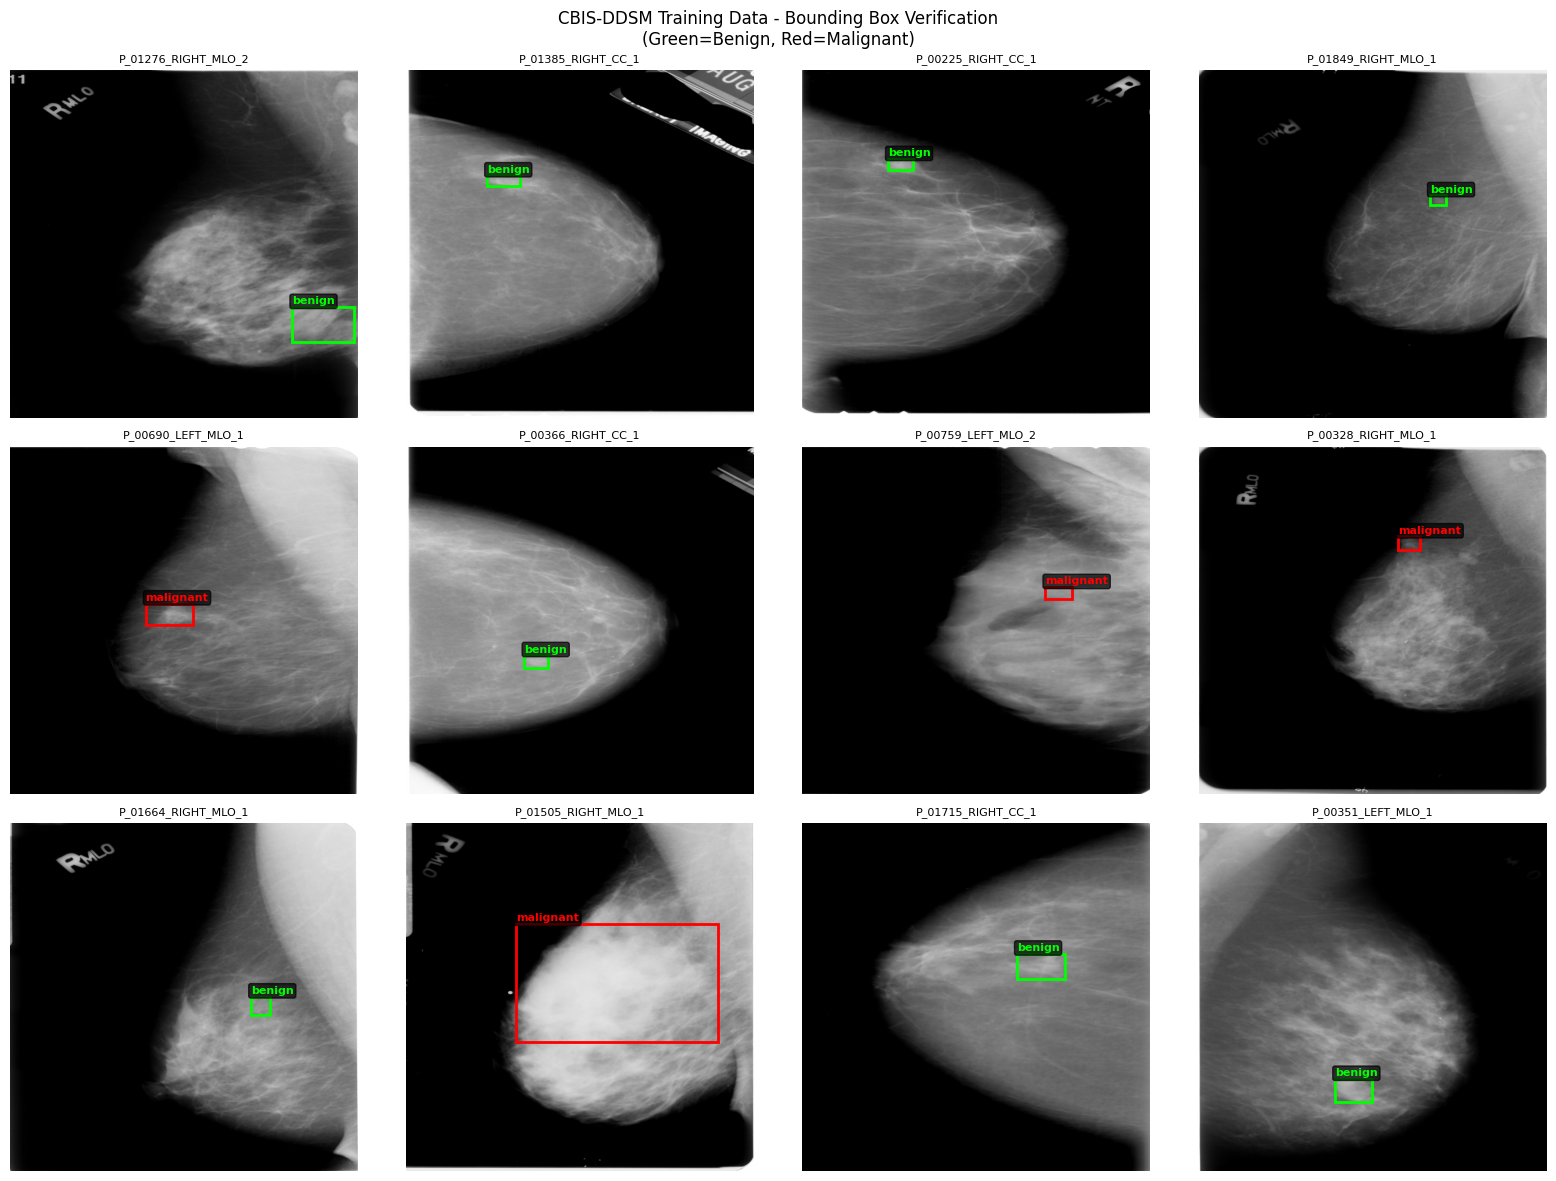


DATASET STATISTICS

Total images: 2433
Total labels: 2433

Class distribution:
  benign: 1429
  malignant: 1004

Bounding box sizes (normalized):
  Width  - min: 0.0081, max: 0.8310, mean: 0.1280
  Height - min: 0.0070, max: 0.6919, mean: 0.0742

⚠️  Tiny boxes (<2% of image): 178
⚠️  Huge boxes (>80% of image): 2


In [ ]:
# =============================================================================
# VERIFY BOUNDING BOXES - NO MODEL NEEDED
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import random

# Your paths
dataset_dir = Path('/content/cbis_ddsm_yolo')  # Update if different
images_dir = dataset_dir / 'images' / 'train'
labels_dir = dataset_dir / 'labels' / 'train'

# Class names
class_names = ['benign', 'malignant']
colors = ['lime', 'red']

# Get random samples
image_files = list(images_dir.glob('*.jpg'))
samples = random.sample(image_files, min(12, len(image_files)))

# Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, img_path in enumerate(samples):
    ax = axes[idx]

    # Load image
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')

    # Load label
    label_path = labels_dir / f"{img_path.stem}.txt"

    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])

                    # Convert normalized to pixels
                    img_w, img_h = img.size
                    x1 = (x_center - width/2) * img_w
                    y1 = (y_center - height/2) * img_h
                    box_w = width * img_w
                    box_h = height * img_h

                    # Draw box
                    color = colors[class_id] if class_id < len(colors) else 'yellow'
                    rect = patches.Rectangle(
                        (x1, y1), box_w, box_h,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)

                    # Label
                    label = class_names[class_id] if class_id < len(class_names) else f'class_{class_id}'
                    ax.text(x1, y1-5, f'{label}', color=color, fontsize=8, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

    ax.set_title(img_path.stem[:25], fontsize=8)
    ax.axis('off')

plt.suptitle('CBIS-DDSM Training Data - Bounding Box Verification\n(Green=Benign, Red=Malignant)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/bbox_verification.png', dpi=150)
plt.show()

# Also print some stats
print("\n" + "="*50)
print("DATASET STATISTICS")
print("="*50)

all_labels = list(labels_dir.glob('*.txt'))
class_counts = {0: 0, 1: 0}
box_sizes = []

for label_path in all_labels:
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                width, height = float(parts[3]), float(parts[4])

                class_counts[class_id] = class_counts.get(class_id, 0) + 1
                box_sizes.append((width, height))

print(f"\nTotal images: {len(list(images_dir.glob('*.jpg')))}")
print(f"Total labels: {len(all_labels)}")
print(f"\nClass distribution:")
for cls_id, count in class_counts.items():
    name = class_names[cls_id] if cls_id < len(class_names) else f'class_{cls_id}'
    print(f"  {name}: {count}")

if box_sizes:
    widths = [s[0] for s in box_sizes]
    heights = [s[1] for s in box_sizes]
    print(f"\nBounding box sizes (normalized):")
    print(f"  Width  - min: {min(widths):.4f}, max: {max(widths):.4f}, mean: {sum(widths)/len(widths):.4f}")
    print(f"  Height - min: {min(heights):.4f}, max: {max(heights):.4f}, mean: {sum(heights)/len(heights):.4f}")

    # Check for suspiciously small or large boxes
    tiny_boxes = sum(1 for w, h in box_sizes if w < 0.02 or h < 0.02)
    huge_boxes = sum(1 for w, h in box_sizes if w > 0.8 or h > 0.8)
    print(f"\n⚠️  Tiny boxes (<2% of image): {tiny_boxes}")
    print(f"⚠️  Huge boxes (>80% of image): {huge_boxes}")


0: 640x640 (no detections), 33.3ms
1: 640x640 (no detections), 33.3ms
2: 640x640 (no detections), 33.3ms
3: 640x640 (no detections), 33.3ms
4: 640x640 (no detections), 33.3ms
5: 640x640 (no detections), 33.3ms
Speed: 1.9ms preprocess, 33.3ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)


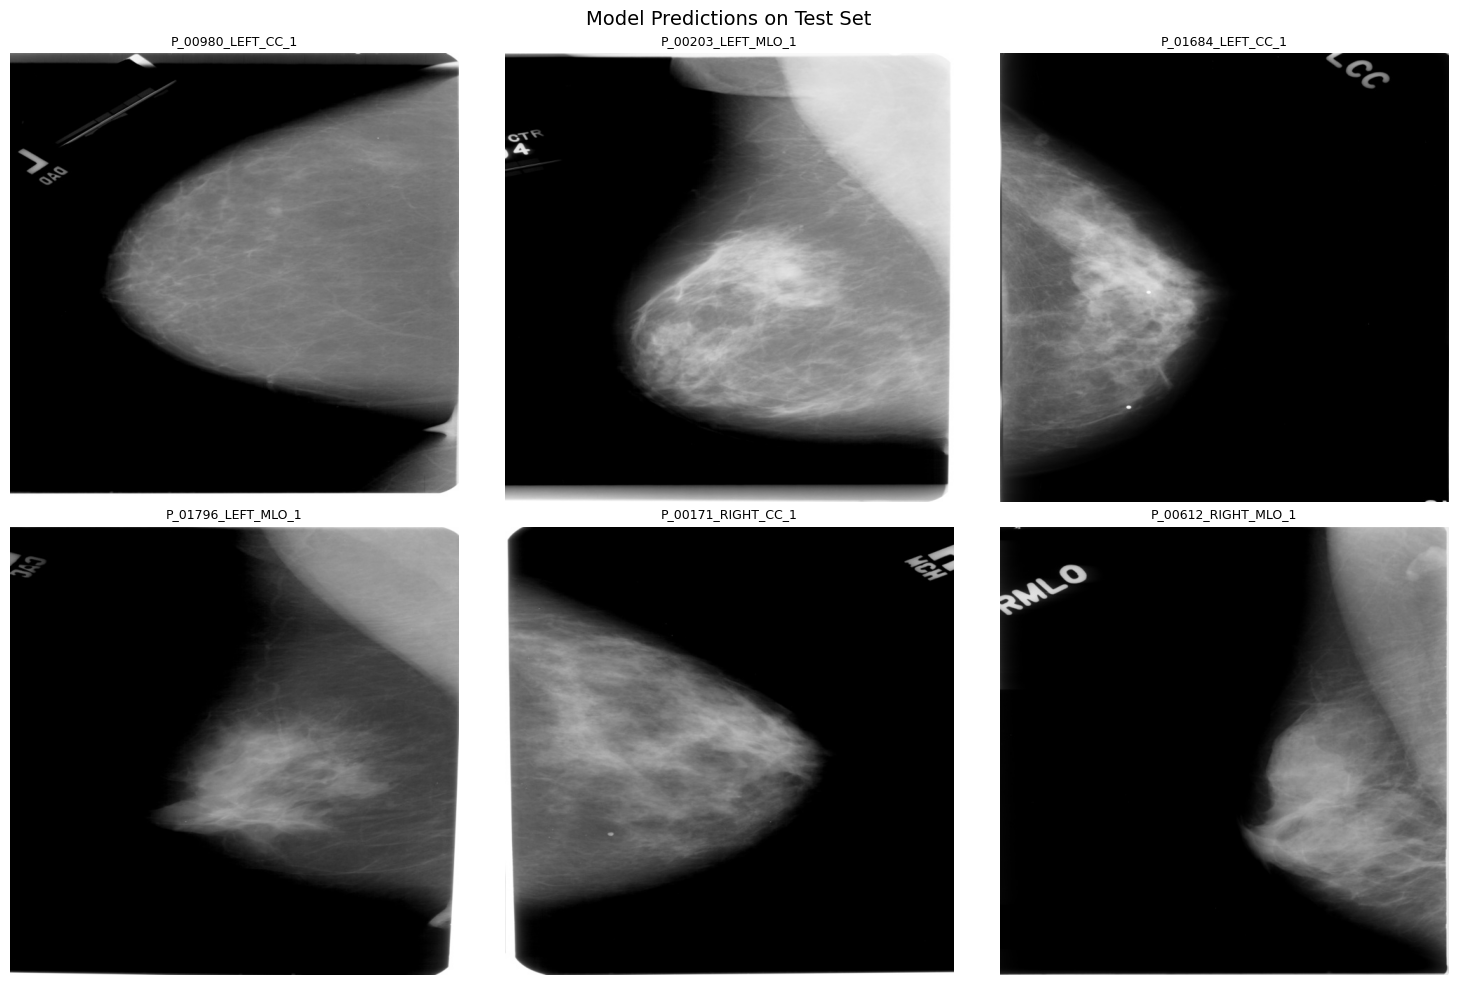

In [ ]:
# Run inference on test images
test_images_dir = Path(config.YOLO_DATASET_DIR) / 'images' / 'test'
test_images = list(test_images_dir.glob('*.jpg'))[:6]

if test_images and 'best_model_path' in dir():
    model = YOLO(best_model_path)

    # Predict
    results = model.predict(
        source=test_images,
        imgsz=config.IMG_SIZE,
        conf=0.25,
        device=0,
        save=False,
    )

    # Visualize
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, (result, img_path) in enumerate(zip(results, test_images)):
        ax = axes[idx]

        # Plot with detections
        img_with_boxes = result.plot()
        ax.imshow(img_with_boxes)
        ax.set_title(img_path.stem[:25], fontsize=9)
        ax.axis('off')

    plt.suptitle('Model Predictions on Test Set', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No test images or model found")

## 8️⃣ Export Model for Deployment

In [ ]:
# Export to ONNX for deployment
if 'best_model_path' in dir():
    model = YOLO(best_model_path)

    # Export to ONNX
    model.export(format='onnx', imgsz=config.IMG_SIZE)

    print(f"\n✓ Model exported to ONNX format")
    print(f"  Location: {best_model_path.parent}")

## 📊 Training Summary

After training completes, your results will be saved to Google Drive at:
- **Model weights:** `{OUTPUT_DIR}/{MODEL}_cbis_ddsm/weights/best.pt`
- **Training curves:** `{OUTPUT_DIR}/{MODEL}_cbis_ddsm/results.png`
- **Metrics:** `{OUTPUT_DIR}/{MODEL}_cbis_ddsm/results.csv`

### Next Steps:
1. Download the best model weights
2. Use for inference in your application
3. Fine-tune hyperparameters if needed
4. Try different model sizes (s, m, l, x) for speed/accuracy tradeoff